# Machine Learning for CICY 4-Folds

H. Erbin, R. Finotello

Following the analysis in [arXiv:2007.13379](https://arxiv.org/abs/2007.13379) and [arXiv:2007.15706](https://arxiv.org/abs/2007.15706), we apply similar concepts to CICY 4-folds.
The idea is to see whether the Inception network can also be applied in higher dimensions.

## Reduced Dataset

In this notebook we produce a dataset containing only the matrix in dense format.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from nn_tools.utils.plotutils import *

In [2]:
sns.set()
ratio   = lambda x, y: (6 * y, 5 * x)

os.makedirs('./img', exist_ok=True)
os.makedirs('./models', exist_ok=True)

In [3]:
random_state = 123
np.random.seed(random_state)

## Download and Read the Dataset

The dataset was first introduced in [arXiv:1405.2073](http://arxiv.org/abs/1405.2073).
The authors provide Hodge numbers and other characteristic invariants of CICY 4-folds.

In [4]:
df = pd.read_json('https://www.lpthe.jussieu.fr/~erbin/files/data/cicy4.json.gz', orient='index')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 921497 entries, 1 to 921497
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   euler   921497 non-null  int64  
 1   favour  921497 non-null  bool   
 2   h11     905684 non-null  float64
 3   h21     905684 non-null  float64
 4   h22     905684 non-null  float64
 5   h31     905684 non-null  float64
 6   isprod  921497 non-null  bool   
 7   matrix  921497 non-null  object 
 8   size    921497 non-null  object 
dtypes: bool(2), float64(4), int64(1), object(2)
memory usage: 58.0+ MB


In order to prepare the dataset we consider only the complete cases (non product spaces) and remove unused columns:

In [6]:
df = df.loc[df['isprod'] == False]

## Data Types Conversion

We then convert the data types of the Hodge numbers for optimisation.

In [7]:
df['h11'] = df['h11'].astype(np.int)
df['h21'] = df['h21'].astype(np.int)
df['h31'] = df['h31'].astype(np.int)
df['h22'] = df['h22'].astype(np.int)

## Padding the Configuration Matrix

We pad the configuration matrix to have a list of 2D matrices having the same shape for training.

In [8]:
# get maximal shape
max_size = df['size'].max()

In [9]:
# pad the matrices
df.loc[:, 'matrix'] = df['matrix'].apply(lambda m: np.pad(m, ((0, max_size[0] - np.shape(m)[0]), (0, max_size[1] - np.shape(m)[1]))))

In [10]:
# drop the columns
df = df.drop(columns=['euler', 'favour', 'isprod', 'size'])

## Visualisation of the Matrices

We finally visualise the input matrices.

In [11]:
max_entry = 0
min_entry = np.inf

# get min e max
for m in df['matrix']:
    if np.max(m) > max_entry:
        max_entry = np.max(m)
    if np.min(m) < min_entry:
        min_entry = np.min(m)

For visualisation purposes we rescale the inputs:

In [12]:
df_tmp = df[['h11', 'h21', 'h31', 'h22']].copy()
df_tmp['matrix'] = df['matrix'].apply(lambda m: (m - min_entry) / (max_entry - min_entry))

We finally visualise them using heatmaps:

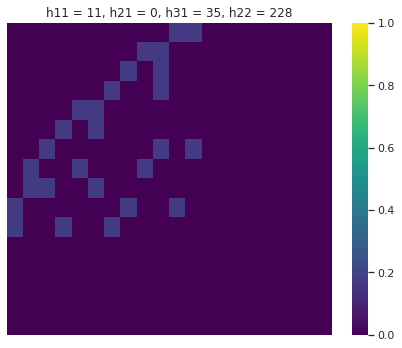

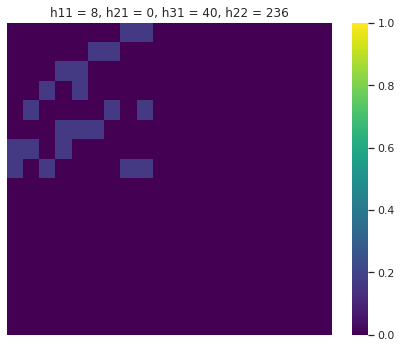

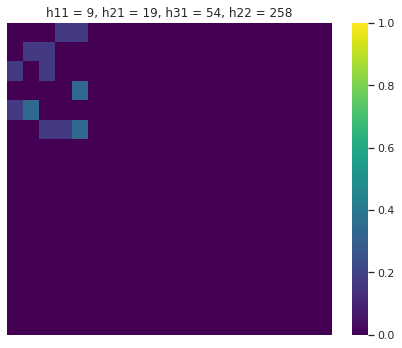

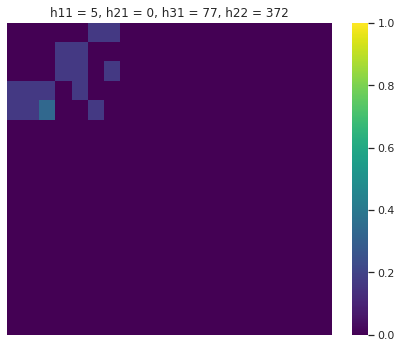

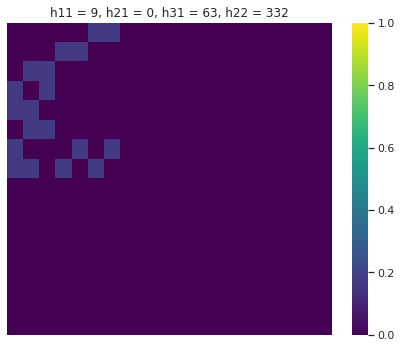

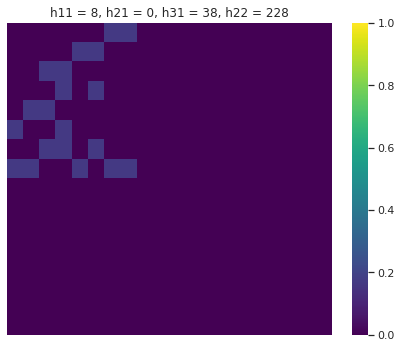

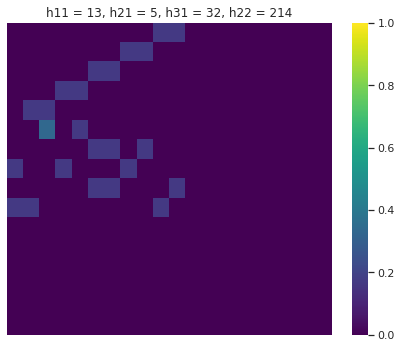

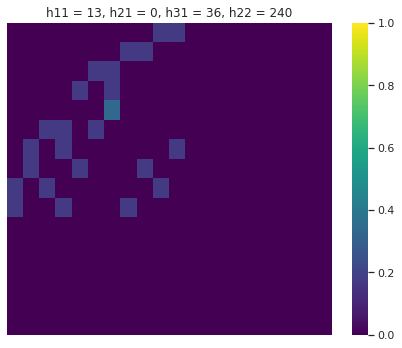

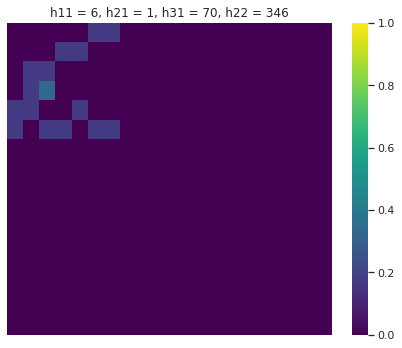

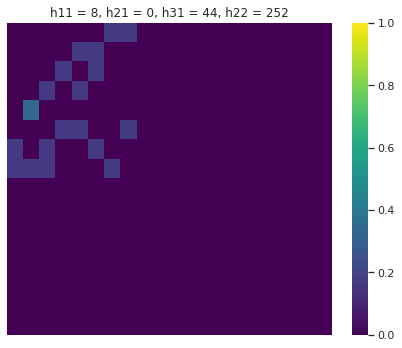

In [13]:
for _ in range(10):
    
    fig, ax = plt.subplots(1, 1, figsize=ratio(1,1))

    rand = np.random.randint(df_tmp.shape[0])

    sns.heatmap(df_tmp.iloc[rand]['matrix'],
                vmin=0.0,
                vmax=1.0,
                cmap='viridis',
                ax=ax
               )
    ax.set(title=f'h11 = {int(df_tmp.iloc[rand]["h11"]):d}, h21 = {int(df_tmp.iloc[rand]["h21"]):d}, h31 = {int(df_tmp.iloc[rand]["h31"]):d}, h22 = {int(df_tmp.iloc[rand]["h22"]):d}',
           xlabel='',
           ylabel='',
           xticklabels='',
           yticklabels=''
          )
    savefig('mat_' + str(rand) + '_heatmap', fig, show=True)

## Save the Dataset

We then save the dataset to file.

In [14]:
# create the directory
os.makedirs('./data', exist_ok=True)

# write the file to file
df.to_json('./data/cicy4_matrix.json.gz', orient='index')